### In today's exercise, we are going to perform an RFM Analysis. This is one of the most widely used models for customer segmentation.

#### This model evaluates 3 key points:
- Recency: How recently a customer made a purchase.
- Frequency: How often a customer makes a purchase.
- Monetary: How much money a customer has spent in total.

In [11]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

# ### Day 9: Customer Segmentation via RFM Analysis
# #### Today we are moving into Sales and Marketing Analytics. We will segment customers based on their purchasing behavior using the RFM model (Recency, Frequency, Monetary).

data = {
    'Customer_ID': ['C-01', 'C-02', 'C-03', 'C-01', 'C-04', 'C-02', 'C-05', 'C-03', 'C-01'],
    'Purchase_Date': ['2026-08-15', '2026-07-20', '2026-09-10', '2026-09-22', '2026-05-11', '2026-09-20', '2026-09-01', '2026-09-18', '2026-09-24'],
    'Transaction_Amount': [150.0, 200.5, 85.0, 300.0, 450.0, 120.0, 600.0, 95.0, 50.0]
}
df_sales = pd.DataFrame(data)

# #### First, we must ensure our date column is in the correct datetime format.
df_sales['Purchase_Date'] = pd.to_datetime(df_sales['Purchase_Date'])

print("Raw Transactional Data:")
display(df_sales)

Raw Transactional Data:


,Customer_ID,Purchase_Date,Transaction_Amount
0,C-01,2026-08-15,150.0
1,C-02,2026-07-20,200.5
2,C-03,2026-09-10,85.0
3,C-01,2026-09-22,300.0
4,C-04,2026-05-11,450.0
5,C-02,2026-09-20,120.0
6,C-05,2026-09-01,600.0
7,C-03,2026-09-18,95.0
8,C-01,2026-09-24,50.0


#### In the first step, we are going to create a new variable representing the current date to calculate the days since the last purchase.

In [12]:
Current_Date = df_sales['Purchase_Date'].max() + dt.timedelta(days=1)


#### For the second step, we are going to segment the customers.

In [15]:
df_rfm = df_sales.groupby('Customer_ID').agg(
    Recency=('Purchase_Date', lambda x: (Current_Date - x.max()).days),
    Frequency=('Customer_ID', 'count'),
    Monetary=('Transaction_Amount', 'sum')
).reset_index()

print("And the final RFM table by customer looks like: ")
display(df_rfm)

And the final RFM table by customer looks like: 


,Customer_ID,Recency,Frequency,Monetary
0,C-01,1,3,500.0
1,C-02,5,2,320.5
2,C-03,7,2,180.0
3,C-04,137,1,450.0
4,C-05,24,1,600.0


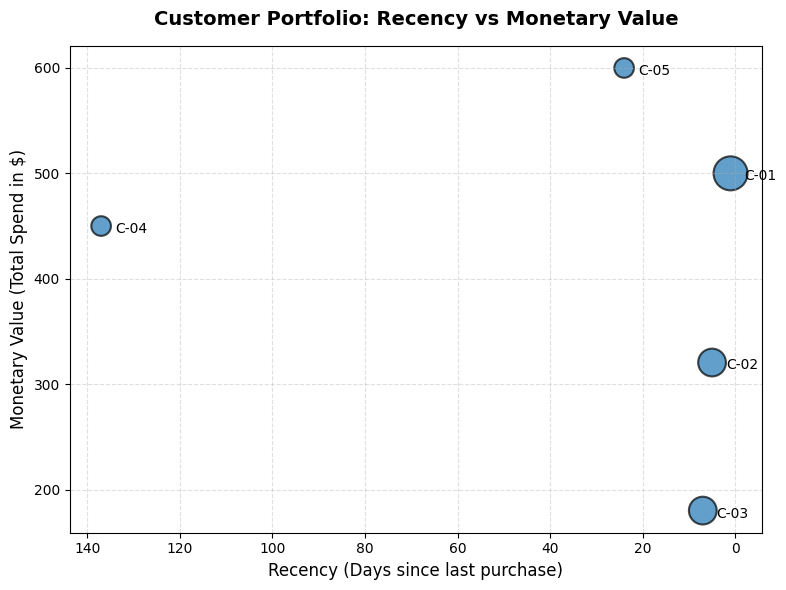

In [14]:
plt.figure(figsize=(8, 6))

sizes = df_rfm['Frequency'] * 200

plt.scatter(
    df_rfm['Recency'], 
    df_rfm['Monetary'], 
    s=sizes, 
    color='#1f77b4', 
    alpha=0.7, 
    edgecolors='black',
    linewidth=1.5
)

plt.title('Customer Portfolio: Recency vs Monetary Value', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary Value (Total Spend in $)', fontsize=12)

plt.gca().invert_xaxis()

for i, txt in enumerate(df_rfm['Customer_ID']):
    plt.annotate(txt, (df_rfm['Recency'][i], df_rfm['Monetary'][i]), 
                 xytext=(10, -5), textcoords='offset points', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()